Import the dependencies

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_covtype

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Class Imbalance (Optional)
from imblearn.over_sampling import SMOTE

# Utilities
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

In [133]:
#making a folder for images
import os

os.makedirs("images", exist_ok=True)

print("Images folder created successfully!")

Images folder created successfully!


Load the dataset

In [2]:
# Load the Forest CoverType dataset
covtype = fetch_covtype()

In [3]:
# Create a DataFrame from the feature matrix
df = pd.DataFrame(
    covtype.data,
    columns=covtype.feature_names
)
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396.0,153.0,20.0,85.0,17.0,108.0,240.0,237.0,118.0,837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581008,2391.0,152.0,19.0,67.0,12.0,95.0,240.0,237.0,119.0,845.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581009,2386.0,159.0,17.0,60.0,7.0,90.0,236.0,241.0,130.0,854.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581010,2384.0,170.0,15.0,60.0,5.0,90.0,230.0,245.0,143.0,864.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Add the target column
df["Cover_Type"] = covtype.target

In [5]:
# printing the dimensions(rows x columns) of the dataset
print(f"Dataset Shape : {df.shape}")

Dataset Shape : (581012, 55)


In [6]:
# printing the first 5 rows of the dataset
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


In [7]:
# printing the last 5 rows of the dataset
df.tail()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
581007,2396.0,153.0,20.0,85.0,17.0,108.0,240.0,237.0,118.0,837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
581008,2391.0,152.0,19.0,67.0,12.0,95.0,240.0,237.0,119.0,845.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
581009,2386.0,159.0,17.0,60.0,7.0,90.0,236.0,241.0,130.0,854.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
581010,2384.0,170.0,15.0,60.0,5.0,90.0,230.0,245.0,143.0,864.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
581011,2383.0,165.0,13.0,60.0,4.0,67.0,231.0,244.0,141.0,875.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


In [8]:
# printing the columns of the dataset
print(f"Columns are :\n {list(df.columns)}")

Columns are :
 ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_0', 'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3', 'Soil_Type_0', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11', 'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15', 'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20', 'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24', 'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28', 'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32', 'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36', 'Soil_Type_37', 'Soil_Type_38', 'Soil_Type_39', 'Cover_Type']


In [9]:
# getting the information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_Area_1         

In [10]:
# getting the statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Elevation,581012.0,2959.365301,279.984734,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.656807,111.913721,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.103704,7.488242,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.428217,212.549356,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.418855,58.295232,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.146611,1559.254870,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.146049,26.769889,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.318716,19.768697,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.528263,38.274529,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.291226,1324.195210,0.0,1024.0,1710.0,2550.0,7173.0


In [11]:
#missing value analysis
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


No missing values were found in the dataset.

In [12]:
#Duplicate check
df.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset

In [13]:
# getting the unique value of the dataset
df.nunique()

,0
Elevation,1978
Aspect,361
Slope,67
Horizontal_Distance_To_Hydrology,551
Vertical_Distance_To_Hydrology,700
Horizontal_Distance_To_Roadways,5785
Hillshade_9am,207
Hillshade_Noon,185
Hillshade_3pm,255
Horizontal_Distance_To_Fire_Points,5827


In [14]:
#target overview
df["Cover_Type"].value_counts(normalize=True)

,proportion
Cover_Type,
2,0.487599
1,0.364605
3,0.061537
7,0.035300
6,0.029891
5,0.016339
4,0.004728


The target distribution is noticeably imbalanced, with Cover Type 1 and 2 accounting for the majority of observations. Class balancing strategies will be considered later after the train-test split.

----

Data Cleaning

In [15]:
# Data Cleaning Verification

print("Missing Values :", df.isnull().sum().sum())
print("Duplicate Rows :", df.duplicated().sum())
print("\nData Types:")
display(df.dtypes.value_counts())

Missing Values : 0
Duplicate Rows : 0

Data Types:


,count
float64,54
int32,1


In [16]:
# Cleaning completed
print(" No data cleaning was required.")

 No data cleaning was required.


### Cleaning Summary

The dataset was inspected for common data quality issues before model development.

**Findings**

- No missing values were detected.
- No duplicate records were found.
- All features have appropriate numerical data types.
- No invalid numerical values were identified.
- Wilderness Area and Soil Type features are already one-hot encoded.

**Decision**

No data cleaning operations were required. The dataset is considered clean and ready for exploratory data analysis.

---

Exploratory Data Analysis (EDA)


In [17]:
# Feature Type Summary
# Continuous numerical features
continuous_features = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

# Binary indicator features
binary_features = [
    col for col in df.columns
    if df[col].nunique() == 2
]

# Target column
target_column = "Cover_Type"

print("="*50)
print("Feature Type Summary")
print("="*50)

print(f"Continuous Features : {len(continuous_features)}")
print(f"Binary Features     : {len(binary_features)}")
print(f"Target Variable     : 1")

print("\nContinuous Features:")
for feature in continuous_features:
    print(f"• {feature}")

Feature Type Summary
Continuous Features : 10
Binary Features     : 44
Target Variable     : 1

Continuous Features:
• Elevation
• Aspect
• Slope
• Horizontal_Distance_To_Hydrology
• Vertical_Distance_To_Hydrology
• Horizontal_Distance_To_Roadways
• Hillshade_9am
• Hillshade_Noon
• Hillshade_3pm
• Horizontal_Distance_To_Fire_Points


In [18]:
# Target Class Distribution
target_counts = df["Cover_Type"].value_counts().sort_index()

target_percent = (
    df["Cover_Type"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percent.round(2)
})

display(target_summary)

,Count,Percentage (%)
Cover_Type,,
1,211840,36.46
2,283301,48.76
3,35754,6.15
4,2747,0.47
5,9493,1.63
6,17367,2.99
7,20510,3.53


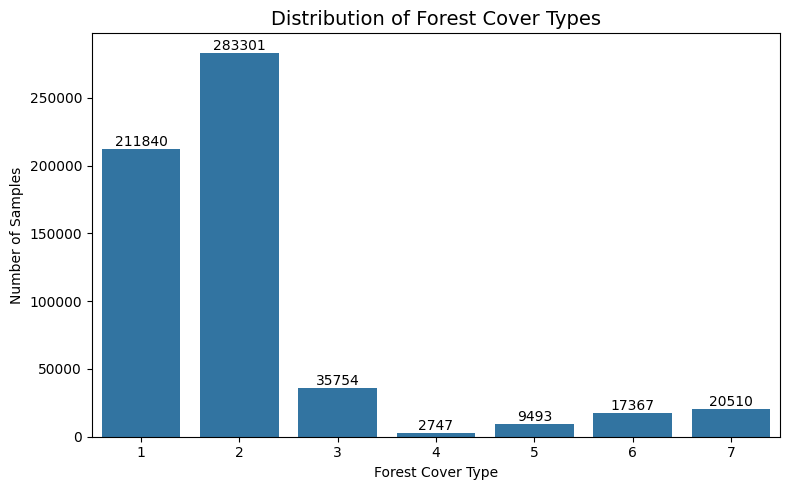

In [134]:
# Target Distribution Visualization
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Cover_Type",
    order=sorted(df["Cover_Type"].unique())
)

plt.title("Distribution of Forest Cover Types", fontsize=14)
plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "images/01_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

The dataset exhibits a noticeable class imbalance. Cover Types 1 and 2 account for approximately 85% of the observations, whereas Classes 4–7 contain comparatively fewer samples. This imbalance will be addressed only on the training data after the train-test split if necessary.

---

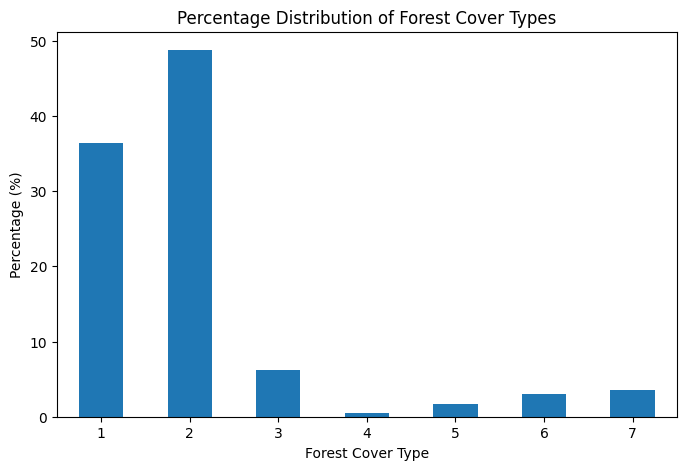

In [20]:
# Percentage Distribution
plt.figure(figsize=(8,5))

(target_percent).plot(
    kind="bar"
)

plt.ylabel("Percentage (%)")
plt.xlabel("Forest Cover Type")
plt.title("Percentage Distribution of Forest Cover Types")

plt.xticks(rotation=0)

plt.show()

In [21]:
# Feature Groups
terrain_features = [
    "Elevation",
    "Aspect",
    "Slope"
]

distance_features = [
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Horizontal_Distance_To_Fire_Points"
]

hillshade_features = [
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm"
]

In [22]:
# Distribution Plot Function
def plot_distribution(features, title):

    n = len(features)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=2,
        figsize=(14, 4*n)
    )

    fig.suptitle(title,
                 fontsize=16,
                 fontweight="bold")

    if n == 1:
        axes = np.array([axes])

    for i, feature in enumerate(features):

        # Histogram
        sns.histplot(
            df[feature],
            kde=True,
            ax=axes[i,0]
        )

        axes[i,0].set_title(f"{feature} Distribution")

        # Boxplot
        sns.boxplot(
            x=df[feature],
            ax=axes[i,1]
        )

        axes[i,1].set_title(f"{feature} Boxplot")

    plt.tight_layout()

    plt.show()

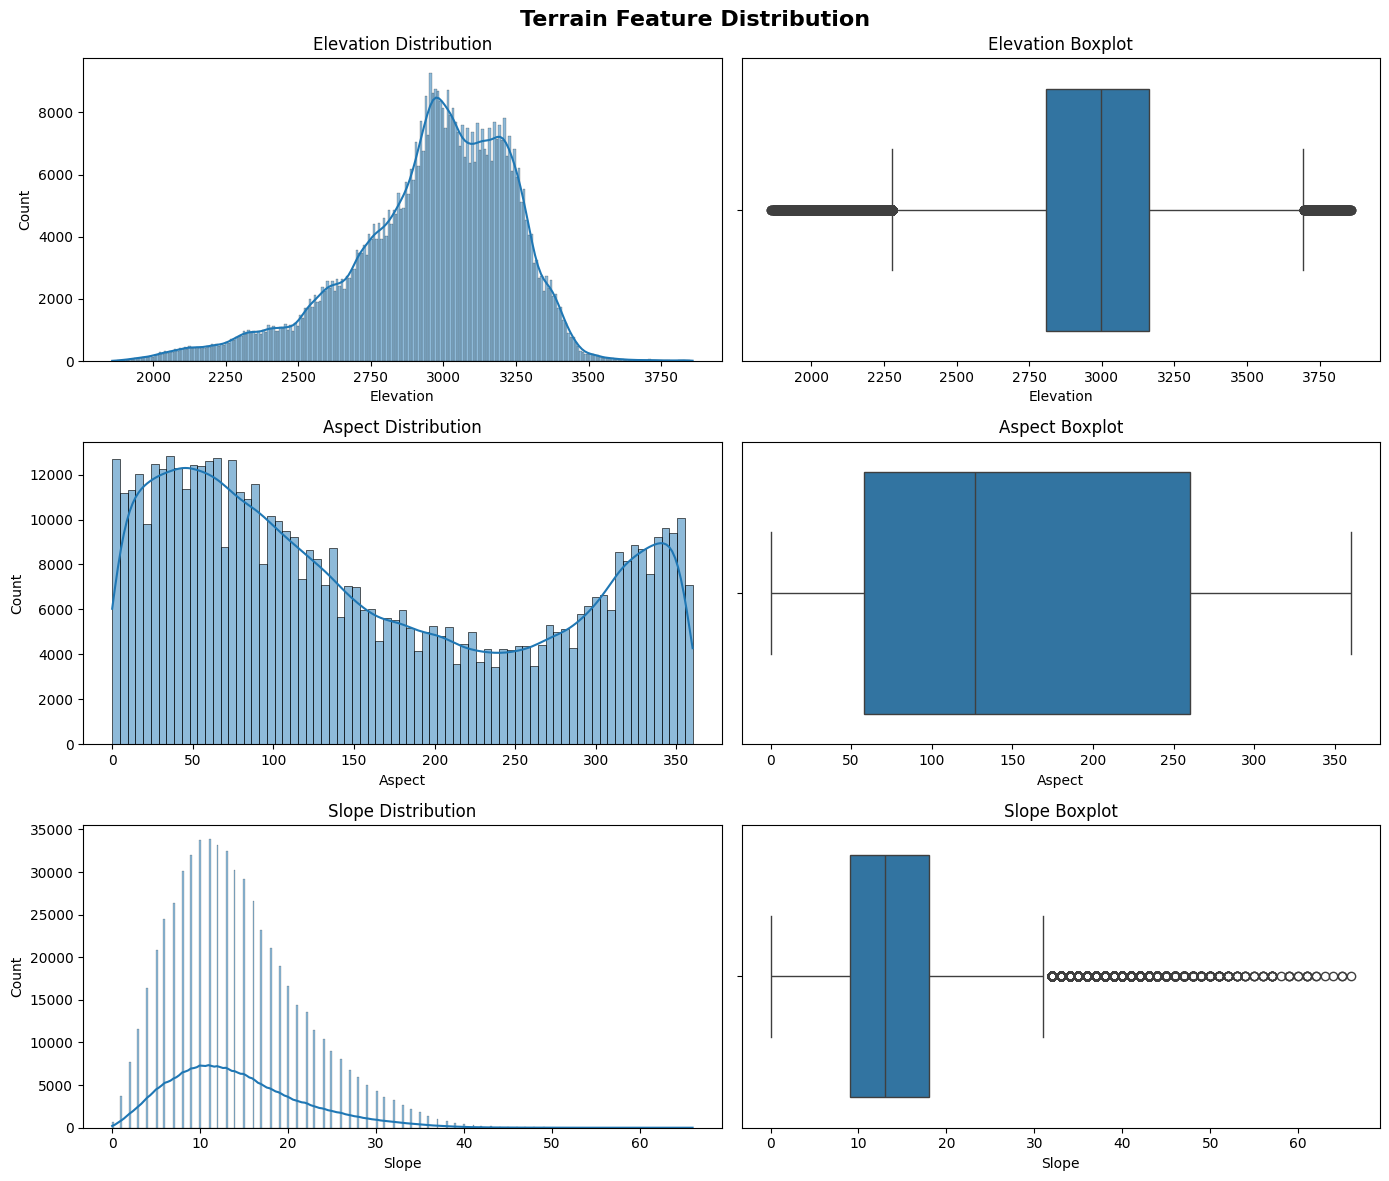

In [23]:
plot_distribution(
    terrain_features,
    "Terrain Feature Distribution"
)

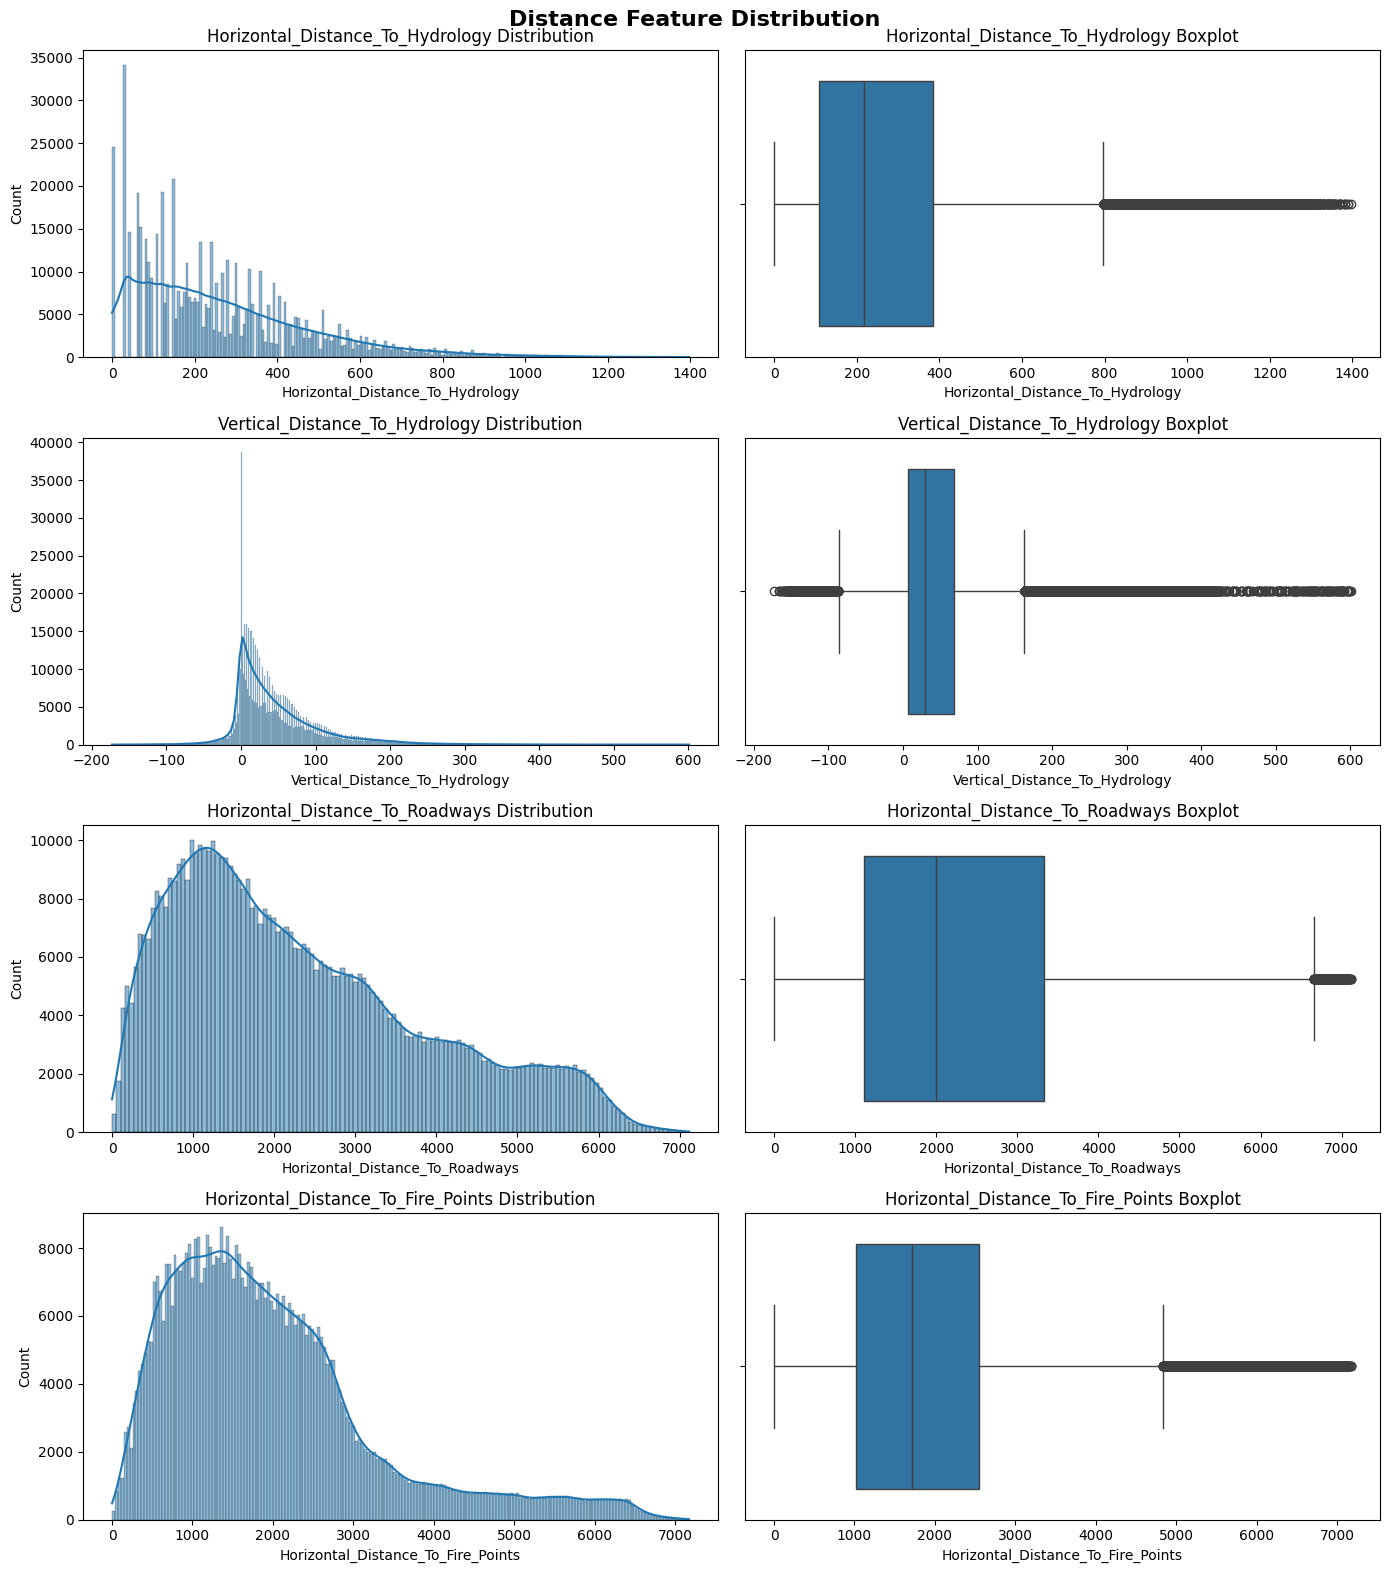

<Figure size 640x480 with 0 Axes>

In [136]:
plot_distribution(
    distance_features,
    "Distance Feature Distribution"
)

plt.tight_layout()

plt.savefig(
    "images/02_feature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

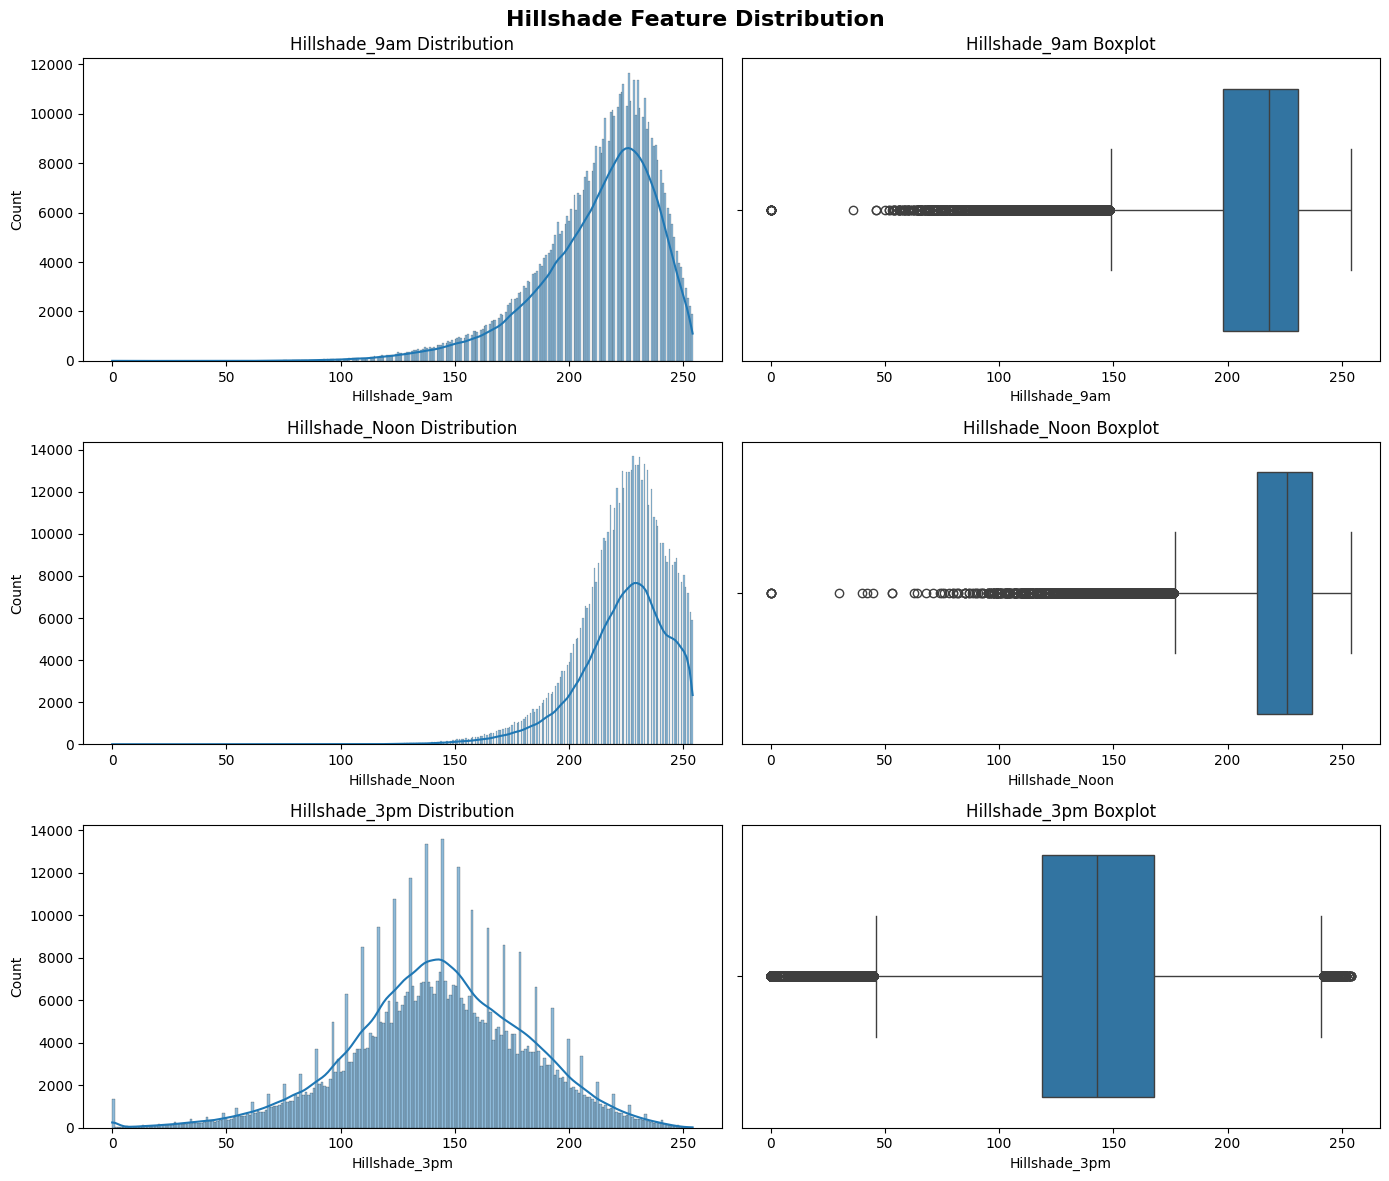

In [25]:
plot_distribution(
    hillshade_features,
    "Hillshade Feature Distribution"
)

In [26]:
#Descriptive Statistics Table
continuous_summary = (
    df[continuous_features]
    .describe()
    .T
    .round(2)
)

display(continuous_summary)

,count,mean,std,min,25%,50%,75%,max
Elevation,581012.0,2959.37,279.98,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.66,111.91,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.10,7.49,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.43,212.55,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.42,58.30,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.15,1559.25,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.15,26.77,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.32,19.77,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.53,38.27,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.29,1324.20,0.0,1024.0,1710.0,2550.0,7173.0


In [27]:
# Binary Feature Groups
wilderness_features = [
    col for col in df.columns
    if col.startswith("Wilderness_Area")
]

soil_features = [
    col for col in df.columns
    if col.startswith("Soil_Type")
]

print(f"Wilderness Features : {len(wilderness_features)}")
print(f"Soil Features       : {len(soil_features)}")

Wilderness Features : 4
Soil Features       : 40


In [28]:
# Activation Percentage
binary_activation = (
    df[binary_features]
    .mean()
    .sort_values(ascending=False)
    * 100
)

binary_activation.head(15)

,0
Wilderness_Area_0,44.886508
Wilderness_Area_2,43.607361
Soil_Type_28,19.835563
Soil_Type_22,9.939898
Soil_Type_31,9.039228
Soil_Type_32,7.771612
Wilderness_Area_3,6.362691
Soil_Type_21,5.743943
Soil_Type_9,5.616751
Soil_Type_29,5.192664


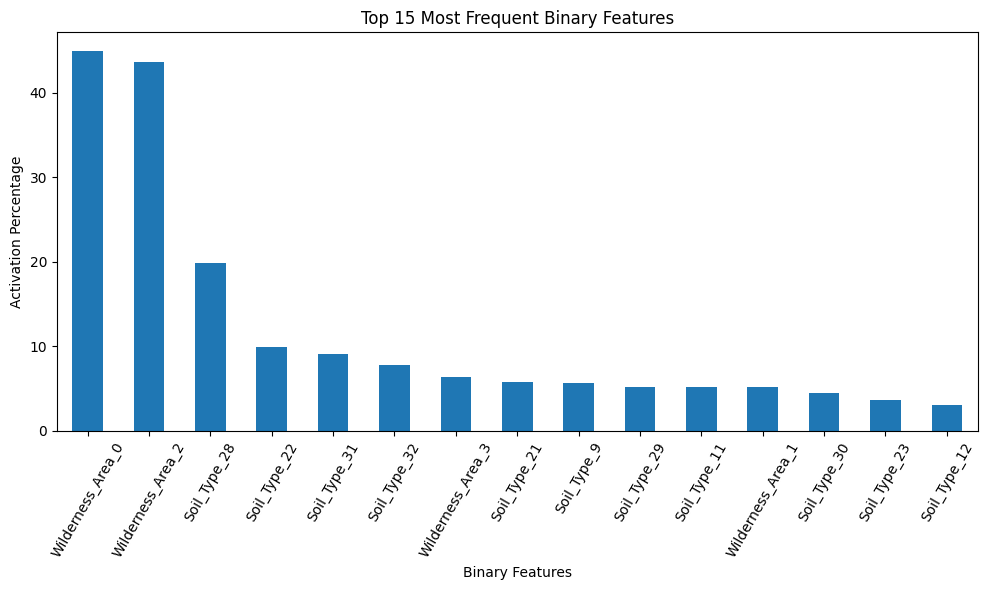

In [29]:
# getting the top activated features
plt.figure(figsize=(10,6))

binary_activation.head(15).plot(kind="bar")

plt.title("Top 15 Most Frequent Binary Features")

plt.ylabel("Activation Percentage")

plt.xlabel("Binary Features")

plt.xticks(rotation=60)

plt.tight_layout()

plt.show()

In [30]:
# Correlation Matrix
corr_matrix = df[continuous_features].corr()

corr_matrix

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
Elevation,1.000000,0.015735,-0.242697,0.306229,0.093306,0.365559,0.112179,0.205887,0.059148,0.148022
Aspect,0.015735,1.000000,0.078728,0.017376,0.070305,0.025121,-0.579273,0.336103,0.646944,-0.109172
Slope,-0.242697,0.078728,1.000000,-0.010607,0.274976,-0.215914,-0.327199,-0.526911,-0.175854,-0.185662
Horizontal_Distance_To_Hydrology,0.306229,0.017376,-0.010607,1.000000,0.606236,0.072030,-0.027088,0.046790,0.052330,0.051874
Vertical_Distance_To_Hydrology,0.093306,0.070305,0.274976,0.606236,1.000000,-0.046372,-0.166333,-0.110957,0.034902,-0.069913
Horizontal_Distance_To_Roadways,0.365559,0.025121,-0.215914,0.072030,-0.046372,1.000000,0.034349,0.189461,0.106119,0.331580
Hillshade_9am,0.112179,-0.579273,-0.327199,-0.027088,-0.166333,0.034349,1.000000,0.010037,-0.780296,0.132669
Hillshade_Noon,0.205887,0.336103,-0.526911,0.046790,-0.110957,0.189461,0.010037,1.000000,0.594274,0.057329
Hillshade_3pm,0.059148,0.646944,-0.175854,0.052330,0.034902,0.106119,-0.780296,0.594274,1.000000,-0.047981
Horizontal_Distance_To_Fire_Points,0.148022,-0.109172,-0.185662,0.051874,-0.069913,0.331580,0.132669,0.057329,-0.047981,1.000000


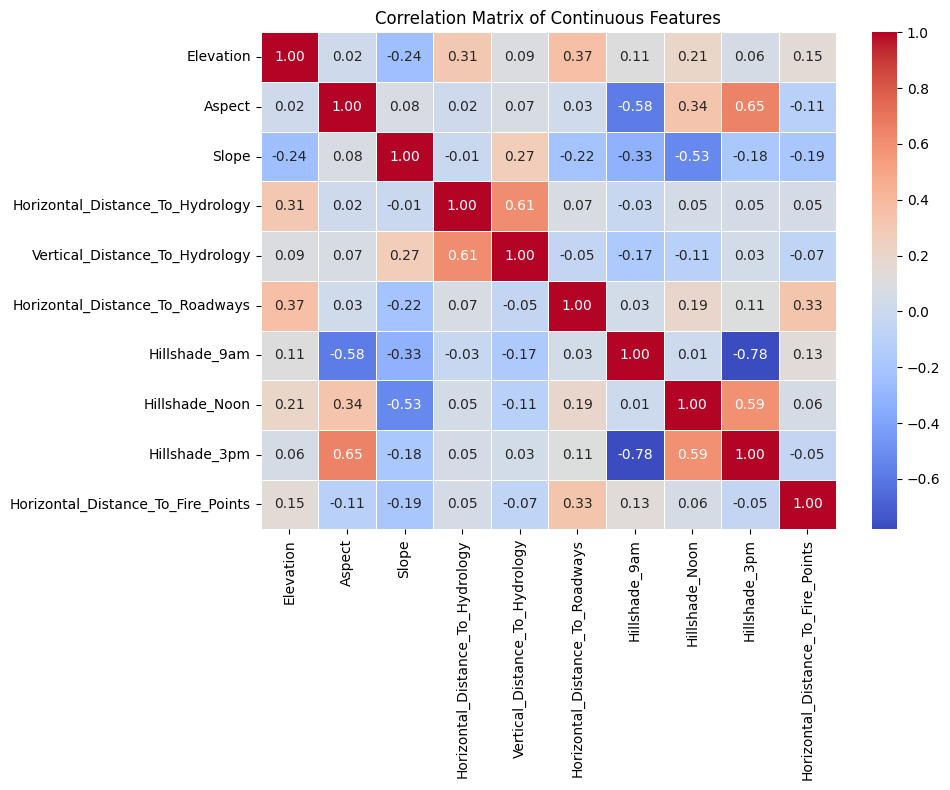

In [135]:
# constructing heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Continuous Features")

plt.tight_layout()
plt.savefig(
    "images/03_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.show()

In [32]:
# Strong Correlations

corr_pairs = (
    corr_matrix
    .abs()
    .unstack()
)

corr_pairs = corr_pairs[
    corr_pairs < 1
]

strong_corr = (
    corr_pairs
    .sort_values(ascending=False)
    .drop_duplicates()
)

strong_corr.head(10)

,,0
Hillshade_9am,Hillshade_3pm,0.780296
Aspect,Hillshade_3pm,0.646944
Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,0.606236
Hillshade_Noon,Hillshade_3pm,0.594274
Hillshade_9am,Aspect,0.579273
Slope,Hillshade_Noon,0.526911
Horizontal_Distance_To_Roadways,Elevation,0.365559
Aspect,Hillshade_Noon,0.336103
Horizontal_Distance_To_Fire_Points,Horizontal_Distance_To_Roadways,0.331580
Hillshade_9am,Slope,0.327199


In [33]:
# Features Selected for Target Relationship Analysis
selected_features = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Horizontal_Distance_To_Fire_Points"
]

In [34]:
# Feature vs Target Visualization
def plot_feature_vs_target(features):

    n = len(features)

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(14,15)
    )

    axes = axes.flatten()

    for ax, feature in zip(axes, features):

        sns.boxplot(
            data=df,
            x="Cover_Type",
            y=feature,
            ax=ax
        )

        ax.set_title(feature)

    plt.tight_layout()

    plt.show()

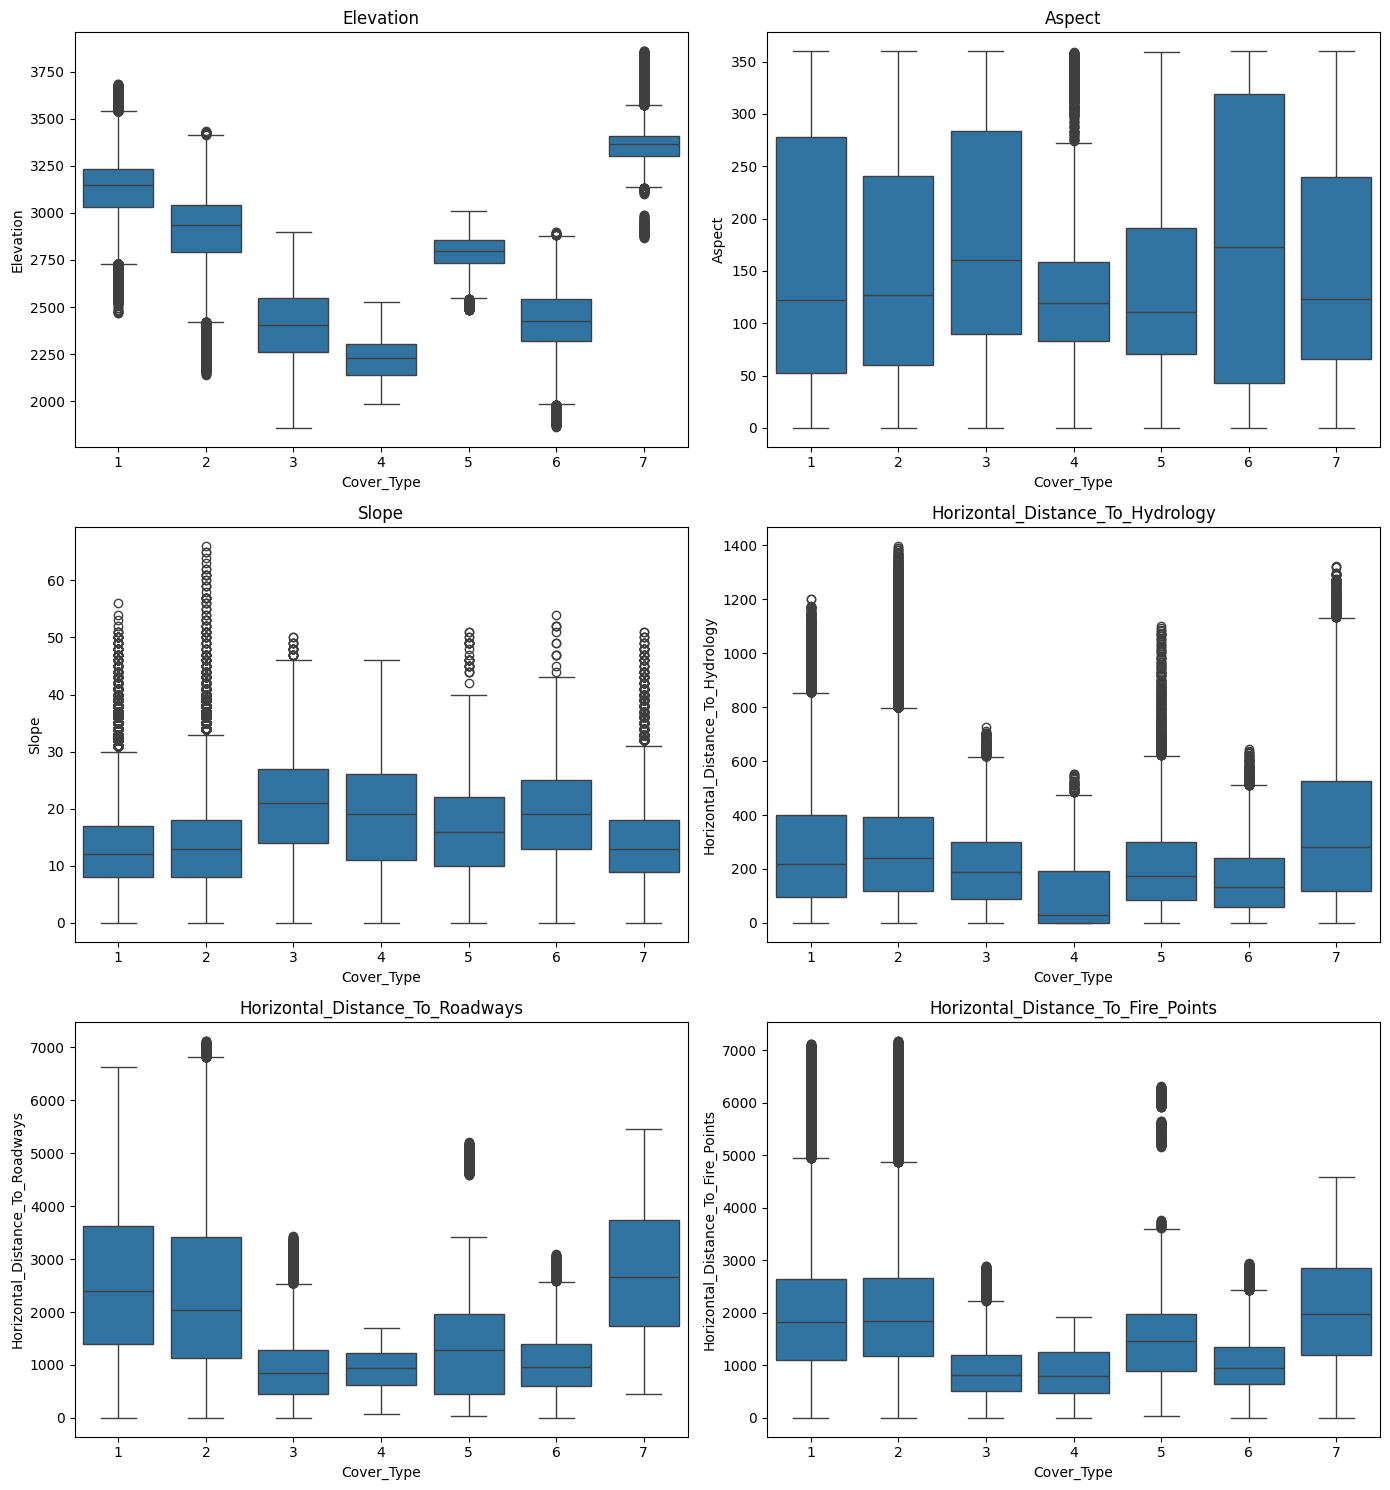

In [35]:
plot_feature_vs_target(selected_features)

In [36]:
# Mean Feature Values by Cover Type
feature_means = (
    df.groupby("Cover_Type")[selected_features]
      .mean()
      .round(2)
)

display(feature_means)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points
Cover_Type,,,,,,
1,3128.64,156.14,13.13,270.56,2614.83,2009.25
2,2920.94,152.06,13.55,279.92,2429.53,2168.15
3,2394.51,176.37,20.77,210.28,943.94,910.96
4,2223.94,137.14,18.53,106.93,914.20,859.12
5,2787.42,139.28,16.64,212.35,1349.77,1577.72
6,2419.18,180.54,19.05,159.85,1037.17,1055.35
7,3361.93,153.24,14.26,356.99,2738.25,2070.03


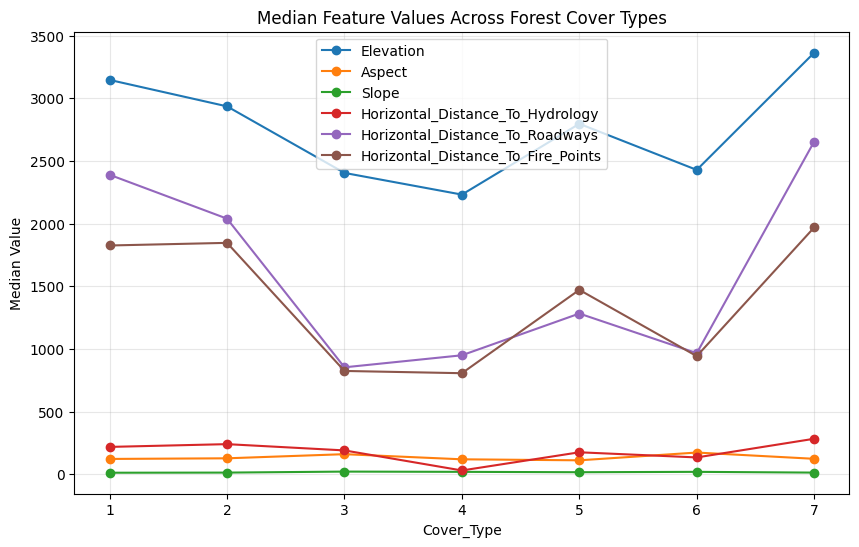

In [37]:
# Median Feature Values by Cover Type
median_values = (
    df.groupby("Cover_Type")[selected_features]
      .median()
)

median_values.plot(
    figsize=(10,6),
    marker="o"
)

plt.title("Median Feature Values Across Forest Cover Types")

plt.ylabel("Median Value")

plt.grid(alpha=0.3)

plt.show()

In [38]:
# IQR-based Outlier Summary
def outlier_summary(dataframe, features):

    summary = []

    for feature in features:

        Q1 = dataframe[feature].quantile(0.25)
        Q3 = dataframe[feature].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = dataframe[
            (dataframe[feature] < lower) |
            (dataframe[feature] > upper)
        ]

        summary.append({
            "Feature": feature,
            "Lower Bound": round(lower,2),
            "Upper Bound": round(upper,2),
            "Outlier Count": len(outliers),
            "Outlier Percentage": round(len(outliers)/len(dataframe)*100,2)
        })

    return pd.DataFrame(summary)

In [39]:
outlier_df = outlier_summary(df, continuous_features)
display(outlier_df)

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Elevation,2278.0,3694.0,15569,2.68
1,Aspect,-245.0,563.0,0,0.00
2,Slope,-4.5,31.5,15316,2.64
3,Horizontal_Distance_To_Hydrology,-306.0,798.0,14557,2.51
4,Vertical_Distance_To_Hydrology,-86.0,162.0,31463,5.42
5,Horizontal_Distance_To_Roadways,-2227.0,6661.0,669,0.12
6,Hillshade_9am,148.5,280.5,17433,3.00
7,Hillshade_Noon,177.0,273.0,15672,2.70
8,Hillshade_3pm,45.5,241.5,7832,1.35
9,Horizontal_Distance_To_Fire_Points,-1265.0,4839.0,31157,5.36


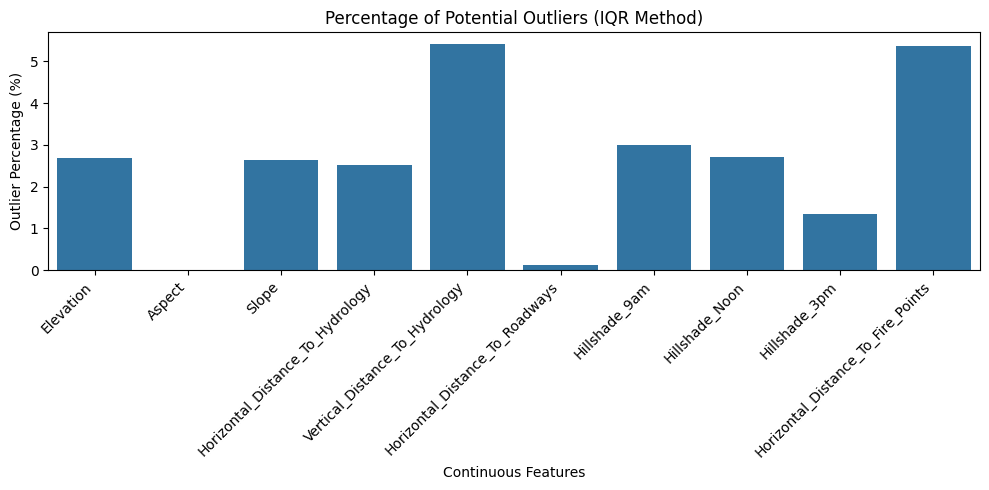

In [143]:
# visualize the outlier
plt.figure(figsize=(10,5))

sns.barplot(
    data=outlier_df,
    x="Feature",
    y="Outlier Percentage"
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Outlier Percentage (%)")

plt.xlabel("Continuous Features")

plt.title("Percentage of Potential Outliers (IQR Method)")

plt.tight_layout()

plt.tight_layout()

plt.savefig(
    "images/04_outlier_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [41]:
outlier_df.sort_values(
    by="Outlier Percentage",
    ascending=False
)

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
4,Vertical_Distance_To_Hydrology,-86.0,162.0,31463,5.42
9,Horizontal_Distance_To_Fire_Points,-1265.0,4839.0,31157,5.36
6,Hillshade_9am,148.5,280.5,17433,3.00
7,Hillshade_Noon,177.0,273.0,15672,2.70
0,Elevation,2278.0,3694.0,15569,2.68
2,Slope,-4.5,31.5,15316,2.64
3,Horizontal_Distance_To_Hydrology,-306.0,798.0,14557,2.51
8,Hillshade_3pm,45.5,241.5,7832,1.35
5,Horizontal_Distance_To_Roadways,-2227.0,6661.0,669,0.12
1,Aspect,-245.0,563.0,0,0.00


Data Preprocess

In [42]:
# Separate Features and Target
X = df.drop(columns="Cover_Type")

y = df["Cover_Type"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (581012, 54)
Target Vector Shape  : (581012,)


In [43]:
# Feature Matrix Verification
print("Number of Features :", X.shape[1])

Number of Features : 54


In [44]:
# Target Verification
display(
    y.value_counts()
      .sort_index()
      .rename("Samples")
)

print("\nUnique Classes:")

print(sorted(y.unique()))

,Samples
Cover_Type,
1,211840
2,283301
3,35754
4,2747
5,9493
6,17367
7,20510



Unique Classes:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]


In [45]:
#feature data types
print(X.dtypes.value_counts())

float64    54
Name: count, dtype: int64


In [46]:
#processing summary table
preprocessing_summary = pd.DataFrame({

    "Step":[

        "Missing Value Imputation",

        "Duplicate Removal",

        "Categorical Encoding",

        "Feature Scaling",

        "Feature Engineering",

        "Feature Selection"

    ],

    "Decision":[

        "Not Required",

        "Not Required",

        "Already Encoded",

        "Not Required",

        "Not Required",

        "All Features Retained"

    ]

})

display(preprocessing_summary)

,Step,Decision
0,Missing Value Imputation,Not Required
1,Duplicate Removal,Not Required
2,Categorical Encoding,Already Encoded
3,Feature Scaling,Not Required
4,Feature Engineering,Not Required
5,Feature Selection,All Features Retained


Train/test/split

In [47]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=RANDOM_STATE

)

In [48]:
# Dataset Split Verification
print("="*50)

print("Training Feature Shape :", X_train.shape)
print("Training Target Shape  :", y_train.shape)

print()

print("Testing Feature Shape  :", X_test.shape)
print("Testing Target Shape   :", y_test.shape)

print("="*50)

Training Feature Shape : (464809, 54)
Training Target Shape  : (464809,)

Testing Feature Shape  : (116203, 54)
Testing Target Shape   : (116203,)


In [49]:
# Verify Target Distribution After Split
train_distribution = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    *100
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .sort_index()
    *100
)

distribution_check = pd.DataFrame({

    "Original (%)": (
        y
        .value_counts(normalize=True)
        .sort_index()
        *100
    ).round(2),

    "Train (%)": train_distribution.round(2),

    "Test (%)": test_distribution.round(2)

})

display(distribution_check)

,Original (%),Train (%),Test (%)
Cover_Type,,,
1,36.46,36.46,36.46
2,48.76,48.76,48.76
3,6.15,6.15,6.15
4,0.47,0.47,0.47
5,1.63,1.63,1.63
6,2.99,2.99,2.99
7,3.53,3.53,3.53


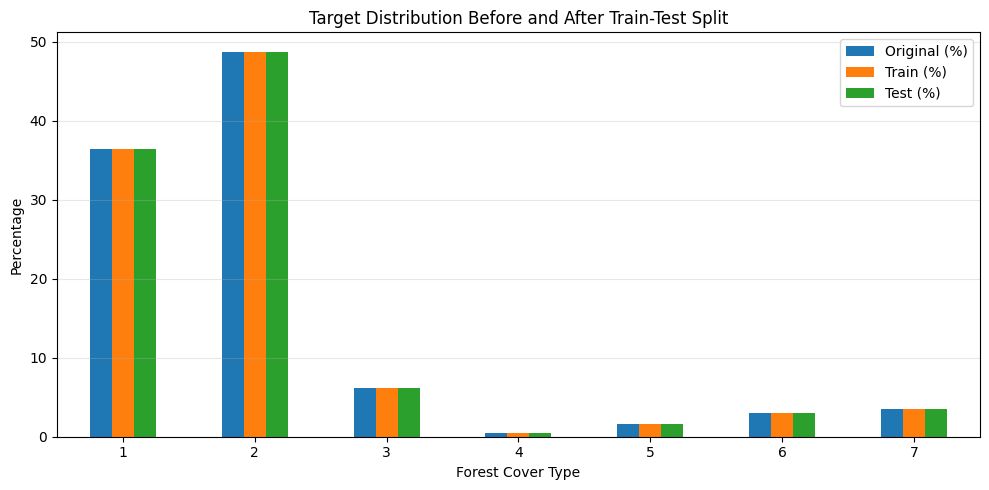

In [50]:
# visualization of train/test/split
distribution_check.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Target Distribution Before and After Train-Test Split")

plt.ylabel("Percentage")

plt.xlabel("Forest Cover Type")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

Imbalance handle

In [51]:
# Class Distribution (Training Set)
train_class_distribution = (
    y_train
    .value_counts()
    .sort_index()
)

train_class_percentage = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    *100
)

imbalance_summary = pd.DataFrame({

    "Count":train_class_distribution,

    "Percentage":train_class_percentage.round(2)

})

display(imbalance_summary)

,Count,Percentage
Cover_Type,,
1,169472,36.46
2,226640,48.76
3,28603,6.15
4,2198,0.47
5,7594,1.63
6,13894,2.99
7,16408,3.53


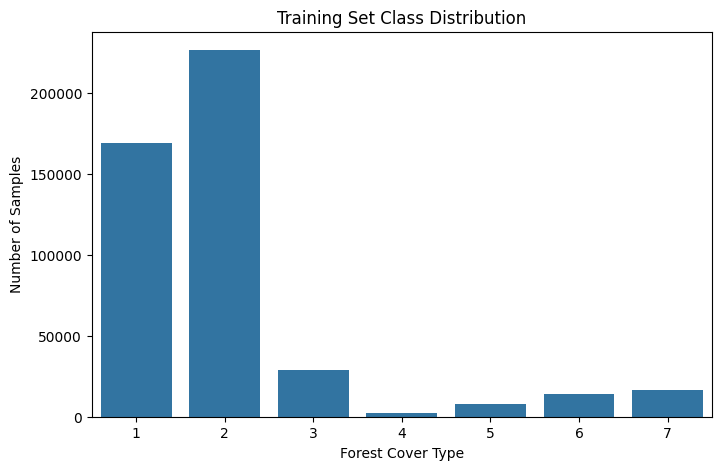

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=y_train,
    order=sorted(y_train.unique())
)

plt.title("Training Set Class Distribution")

plt.xlabel("Forest Cover Type")

plt.ylabel("Number of Samples")

plt.show()

### Observation

The training set preserves the original class imbalance observed in the full dataset.

Although minority classes contain substantially fewer observations than the majority classes, no resampling is performed at this stage.

A baseline Random Forest model will first be trained on the original data.

The necessity of SMOTE or other balancing techniques will be determined based on class-wise evaluation metrics, particularly recall and the confusion matrix.

---

Train RF model

In [53]:
# Initialize Baseline Random Forest Model
rf_baseline = RandomForestClassifier(

    n_estimators=100,

    random_state=RANDOM_STATE,

    n_jobs=-1

)

In [54]:
# Train Random Forest
rf_baseline.fit(

    X_train,

    y_train

)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [55]:
# Prediction on Test Set
y_pred_rf = rf_baseline.predict(

    X_test

)

In [56]:
# Accuracy
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(f"Accuracy : {rf_accuracy:.4f}")

Accuracy : 0.9533


In [57]:
# Precision

rf_precision_macro = precision_score(
    y_test,
    y_pred_rf,
    average="macro"
)

rf_precision_weighted = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print(f"Macro Precision    : {rf_precision_macro:.4f}")
print(f"Weighted Precision : {rf_precision_weighted:.4f}")

Macro Precision    : 0.9463
Weighted Precision : 0.9535


In [58]:
# Recall

rf_recall_macro = recall_score(
    y_test,
    y_pred_rf,
    average="macro"
)

rf_recall_weighted = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print(f"Macro Recall    : {rf_recall_macro:.4f}")
print(f"Weighted Recall : {rf_recall_weighted:.4f}")

Macro Recall    : 0.9053
Weighted Recall : 0.9533


In [59]:
# F1 Score

rf_f1_macro = f1_score(
    y_test,
    y_pred_rf,
    average="macro"
)

rf_f1_weighted = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print(f"Macro F1 Score    : {rf_f1_macro:.4f}")
print(f"Weighted F1 Score : {rf_f1_weighted:.4f}")

Macro F1 Score    : 0.9241
Weighted F1 Score : 0.9531


In [60]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           1       0.96      0.94      0.95     42368
           2       0.95      0.97      0.96     56661
           3       0.94      0.96      0.95      7151
           4       0.92      0.86      0.89       549
           5       0.95      0.77      0.85      1899
           6       0.93      0.89      0.91      3473
           7       0.97      0.95      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.95      0.91      0.92    116203
weighted avg       0.95      0.95      0.95    116203



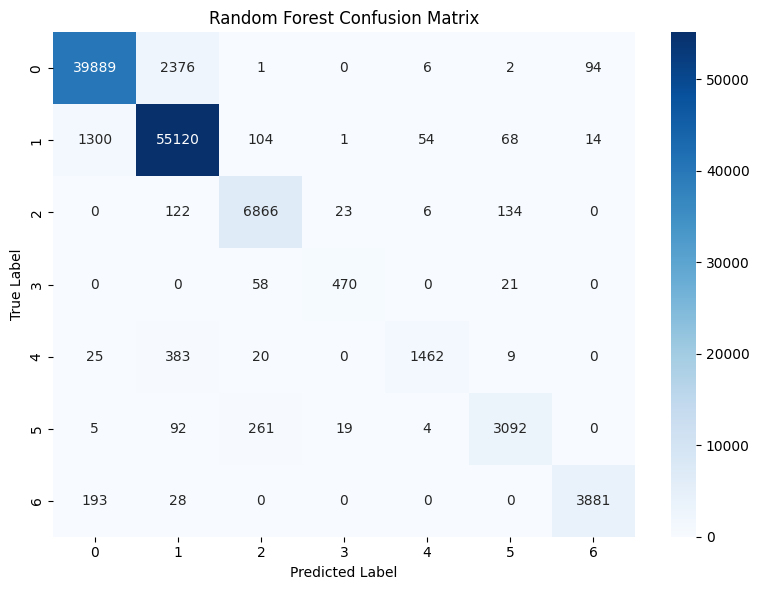

In [138]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "images/05_random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
# Performance Summary
rf_summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision (Macro)",

        "Precision (Weighted)",

        "Recall (Macro)",

        "Recall (Weighted)",

        "F1 Score (Macro)",

        "F1 Score (Weighted)"

    ],

    "Score":[

        rf_accuracy,

        rf_precision_macro,

        rf_precision_weighted,

        rf_recall_macro,

        rf_recall_weighted,

        rf_f1_macro,

        rf_f1_weighted

    ]

})

rf_summary["Score"] = rf_summary["Score"].round(4)

display(rf_summary)

,Metric,Score
0,Accuracy,0.9533
1,Precision (Macro),0.9463
2,Precision (Weighted),0.9535
3,Recall (Macro),0.9053
4,Recall (Weighted),0.9533
5,F1 Score (Macro),0.9241
6,F1 Score (Weighted),0.9531


In [63]:
# Extract Feature Importance
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_baseline.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance.head(15))

,Feature,Importance
0,Elevation,0.240072
1,Horizontal_Distance_To_Roadways,0.118071
2,Horizontal_Distance_To_Fire_Points,0.110950
3,Horizontal_Distance_To_Hydrology,0.060759
4,Vertical_Distance_To_Hydrology,0.057779
5,Aspect,0.048021
6,Hillshade_Noon,0.042969
7,Hillshade_9am,0.041077
8,Hillshade_3pm,0.040795
9,Slope,0.032945


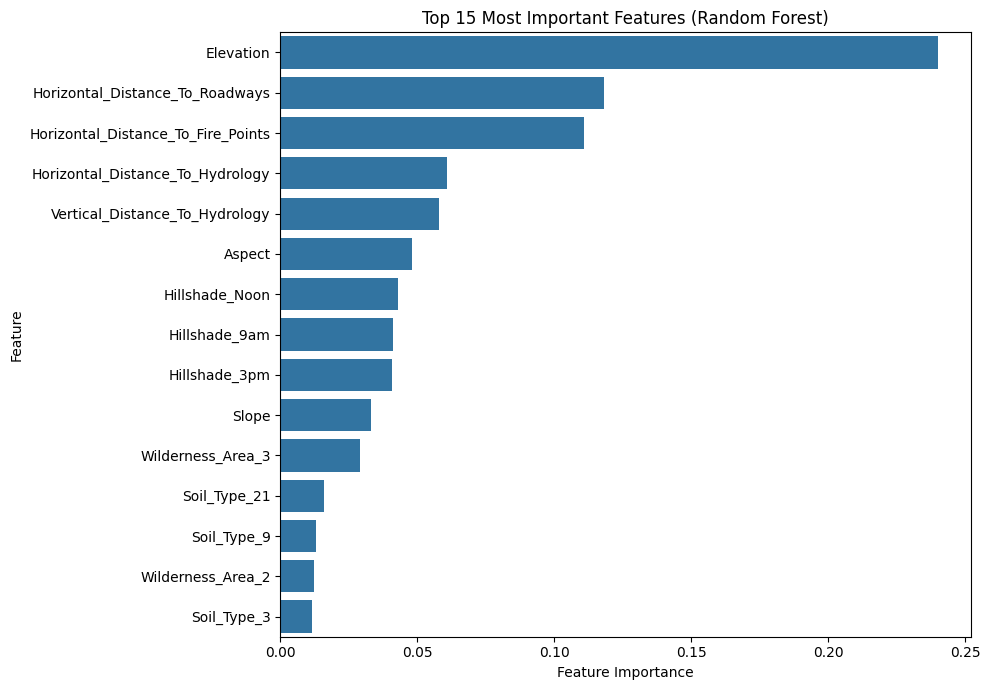

In [139]:
# Top 15 Most Important Features
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Most Important Features (Random Forest)"
)

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "images/06_random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
# Cumulative Feature Importance
feature_importance["Cumulative Importance"] = (
    feature_importance["Importance"]
    .cumsum()
)

display(
    feature_importance.head(15)
)

,Feature,Importance,Cumulative Importance
0,Elevation,0.240072,0.240072
1,Horizontal_Distance_To_Roadways,0.118071,0.358143
2,Horizontal_Distance_To_Fire_Points,0.110950,0.469093
3,Horizontal_Distance_To_Hydrology,0.060759,0.529852
4,Vertical_Distance_To_Hydrology,0.057779,0.587631
5,Aspect,0.048021,0.635652
6,Hillshade_Noon,0.042969,0.678622
7,Hillshade_9am,0.041077,0.719698
8,Hillshade_3pm,0.040795,0.760493
9,Slope,0.032945,0.793438


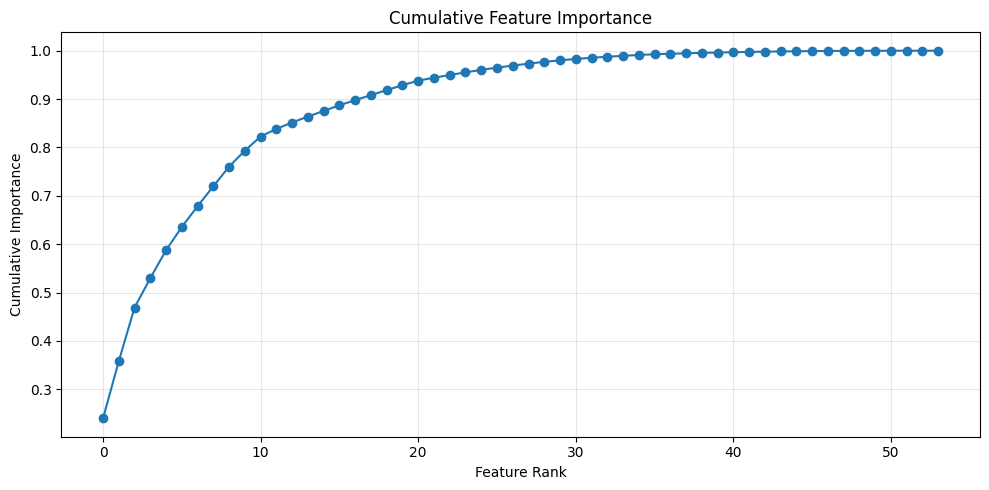

In [66]:
#visualize the cumulative feature importance
plt.figure(figsize=(10,5))

plt.plot(
    feature_importance["Cumulative Importance"],
    marker="o"
)

plt.xlabel("Feature Rank")

plt.ylabel("Cumulative Importance")

plt.title("Cumulative Feature Importance")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [67]:
#making a table for better understanding of importance features
top10 = (
    feature_importance
    .head(10)
    .copy()
)

top10["Importance (%)"] = (
    top10["Importance"] * 100
).round(2)

display(
    top10[
        ["Feature",
         "Importance (%)"]
    ]
)

,Feature,Importance (%)
0,Elevation,24.01
1,Horizontal_Distance_To_Roadways,11.81
2,Horizontal_Distance_To_Fire_Points,11.10
3,Horizontal_Distance_To_Hydrology,6.08
4,Vertical_Distance_To_Hydrology,5.78
5,Aspect,4.80
6,Hillshade_Noon,4.30
7,Hillshade_9am,4.11
8,Hillshade_3pm,4.08
9,Slope,3.29


XGBoost Baseline

In [68]:
# Initialize XGBoost Baseline
xgb_baseline = XGBClassifier(

    objective="multi:softmax",

    num_class=7,

    n_estimators=100,

    random_state=RANDOM_STATE,

    eval_metric="mlogloss",

    n_jobs=-1
)

In [69]:
# Encode Target Labels for XGBoost
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)

y_test_xgb = label_encoder.transform(y_test)

In [70]:
#verification
print("Original Classes :", sorted(y.unique()))
print("Encoded Classes  :", sorted(np.unique(y_train_xgb)))

Original Classes : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]
Encoded Classes  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [71]:
# Train XGBoost


xgb_baseline.fit(
    X_train,
    y_train_xgb
)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1, num_class=7, ...)

In [72]:
# Prediction
y_pred_encoded = xgb_baseline.predict(X_test)


In [73]:
# Convert Back to Original Labels
y_pred_xgb = label_encoder.inverse_transform(y_pred_encoded)

print("Prediction Shape :", y_pred_xgb.shape)

print("Prediction Classes :", np.unique(y_pred_xgb))

Prediction Shape : (116203,)
Prediction Classes : [1 2 3 4 5 6 7]


In [74]:
# Accuracy
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

print(f"Accuracy : {xgb_accuracy:.4f}")

Accuracy : 0.8682


In [75]:
#precession
xgb_precision_macro = precision_score(
    y_test,
    y_pred_xgb,
    average="macro"
)

xgb_precision_weighted = precision_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

print(f"Macro Precision    : {xgb_precision_macro:.4f}")
print(f"Weighted Precision : {xgb_precision_weighted:.4f}")

Macro Precision    : 0.8764
Weighted Precision : 0.8681


In [76]:
#recall
xgb_recall_macro = recall_score(
    y_test,
    y_pred_xgb,
    average="macro"
)

xgb_recall_weighted = recall_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

print(f"Macro Recall    : {xgb_recall_macro:.4f}")
print(f"Weighted Recall : {xgb_recall_weighted:.4f}")

Macro Recall    : 0.8305
Weighted Recall : 0.8682


In [77]:
#F1 score
xgb_f1_macro = f1_score(
    y_test,
    y_pred_xgb,
    average="macro"
)

xgb_f1_weighted = f1_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

print(f"Macro F1 Score    : {xgb_f1_macro:.4f}")
print(f"Weighted F1 Score : {xgb_f1_weighted:.4f}")

Macro F1 Score    : 0.8508
Weighted F1 Score : 0.8677


In [78]:
#classification report
print(classification_report(
    y_test,
    y_pred_xgb
))

              precision    recall  f1-score   support

           1       0.86      0.84      0.85     42368
           2       0.87      0.89      0.88     56661
           3       0.89      0.91      0.90      7151
           4       0.88      0.83      0.85       549
           5       0.87      0.64      0.74      1899
           6       0.83      0.78      0.81      3473
           7       0.94      0.92      0.93      4102

    accuracy                           0.87    116203
   macro avg       0.88      0.83      0.85    116203
weighted avg       0.87      0.87      0.87    116203



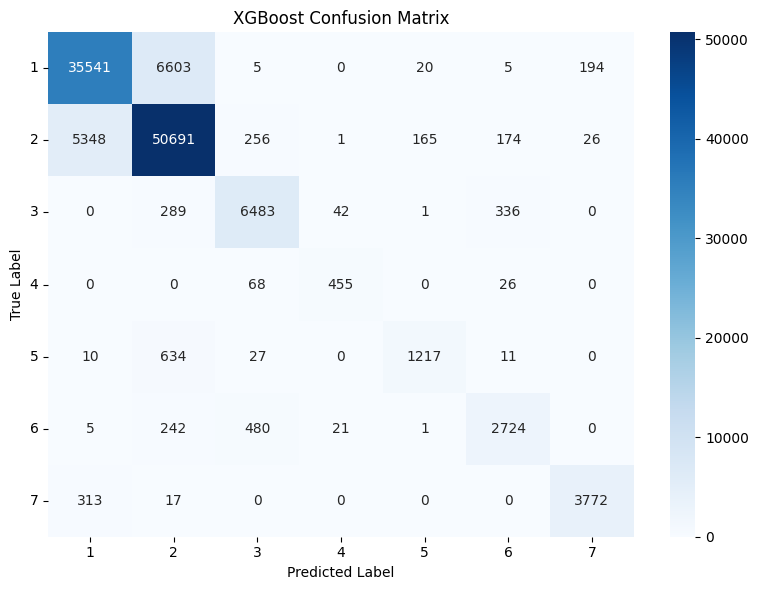

In [140]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.xticks(
    np.arange(7)+0.5,
    labels=[1,2,3,4,5,6,7]
)

plt.yticks(
    np.arange(7)+0.5,
    labels=[1,2,3,4,5,6,7],
    rotation=0
)

plt.tight_layout()
plt.savefig(
    "images/07_xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
#performance summary
xgb_summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision (Macro)",

        "Precision (Weighted)",

        "Recall (Macro)",

        "Recall (Weighted)",

        "F1 Score (Macro)",

        "F1 Score (Weighted)"

    ],

    "Score":[

        xgb_accuracy,

        xgb_precision_macro,

        xgb_precision_weighted,

        xgb_recall_macro,

        xgb_recall_weighted,

        xgb_f1_macro,

        xgb_f1_weighted

    ]

})

xgb_summary["Score"] = xgb_summary["Score"].round(4)

display(xgb_summary)

,Metric,Score
0,Accuracy,0.8682
1,Precision (Macro),0.8764
2,Precision (Weighted),0.8681
3,Recall (Macro),0.8305
4,Recall (Weighted),0.8682
5,F1 Score (Macro),0.8508
6,F1 Score (Weighted),0.8677


In [81]:
#Feature Importance
xgb_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb_baseline.feature_importances_

})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

display(xgb_importance.head(15))

,Feature,Importance
16,Soil_Type_2,0.097762
0,Elevation,0.074297
52,Soil_Type_38,0.048299
45,Soil_Type_31,0.048214
10,Wilderness_Area_0,0.048109
15,Soil_Type_1,0.043448
12,Wilderness_Area_2,0.042396
35,Soil_Type_21,0.037923
17,Soil_Type_3,0.036855
25,Soil_Type_11,0.029412


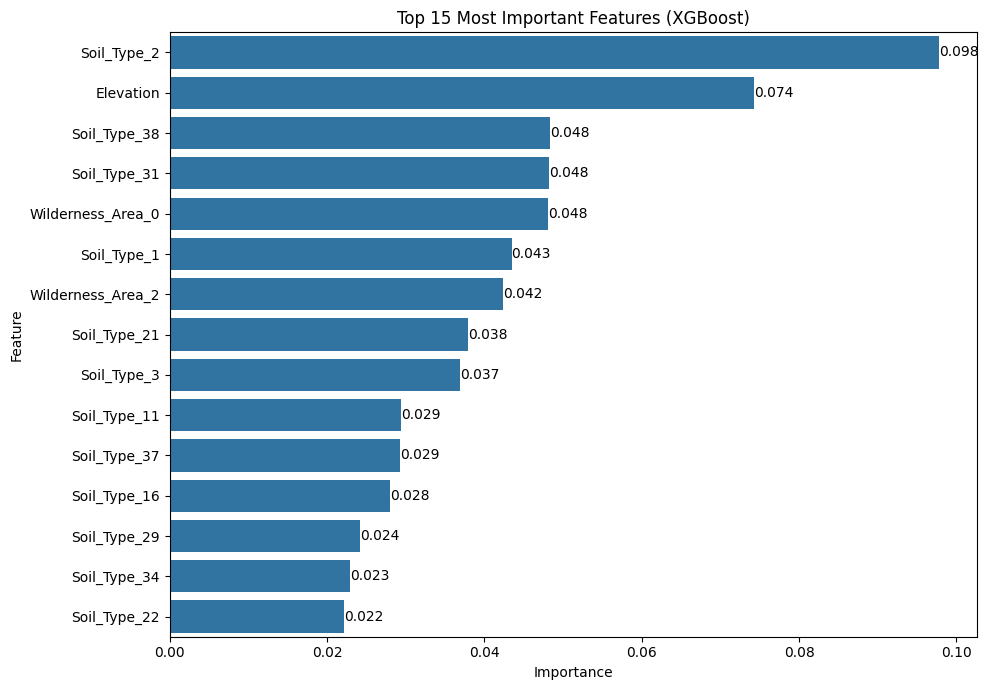

In [141]:
#visualize the feature improtance
top_features = xgb_importance.head(15)

plt.figure(figsize=(10,7))

ax = sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features (XGBoost)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.savefig(
    "images/08_xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Hypermeter Tuning -Random Forest Tuning

In [83]:
# Create Stratified Tuning Dataset
from sklearn.model_selection import train_test_split

X_tune, _, y_tune, _ = train_test_split(

    X_train,

    y_train,

    train_size=0.30,

    stratify=y_train,

    random_state=RANDOM_STATE

)

print("="*50)

print("Hyperparameter Tuning Dataset")

print("="*50)

print(f"Tuning Samples : {X_tune.shape[0]:,}")

print(f"Features        : {X_tune.shape[1]}")

Hyperparameter Tuning Dataset
Tuning Samples : 139,442
Features        : 54


In [84]:
# Random Forest Hyperparameter Search Space
rf_param_grid = {

    "n_estimators":[
        100,
        200,
        300
    ],

    "max_depth":[
        None,
        20,
        30,
        40
    ],

    "min_samples_split":[
        2,
        5,
        10
    ],

    "min_samples_leaf":[
        1,
        2,
        4
    ],

    "max_features":[
        "sqrt",
        "log2"
    ]

}

print("Total Search Dimensions :", len(rf_param_grid))

Total Search Dimensions : 5


In [85]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

rf_random = RandomizedSearchCV(

    estimator=RandomForestClassifier(

        random_state=RANDOM_STATE,

        n_jobs=-1

    ),

    param_distributions=rf_param_grid,

    n_iter=10,

    cv=3,

    scoring="f1_macro",

    random_state=RANDOM_STATE,

    verbose=2,

    n_jobs=-1

)

In [86]:
# Random Forest Hyperparameter Optimization

import time

start_time = time.time()

rf_random.fit(

    X_tune,

    y_tune

)

end_time = time.time()

rf_tuning_time = end_time - start_time

print("="*50)

print(f"Tuning Time : {rf_tuning_time:.2f} seconds")

print("="*50)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Tuning Time : 980.13 seconds


In [88]:
# Best Parameters
print("="*50)

print("Best Random Forest Parameters")

print("="*50)

print(rf_random.best_params_)

Best Random Forest Parameters
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [89]:
# Best Cross Validation Score

print("="*50)

print("Best Cross Validation Macro F1")

print("="*50)

print(f"{rf_random.best_score_:.4f}")

Best Cross Validation Macro F1
0.8324


In [90]:
# Best Estimator
rf_best = rf_random.best_estimator_

print(rf_best)

RandomForestClassifier(max_depth=30, min_samples_split=5, n_jobs=-1,
                       random_state=42)


In [91]:
# Retrain Best Model Using Full Training Dataset
start_train = time.time()

rf_best.fit(

    X_train,

    y_train

)

end_train = time.time()

rf_best_training_time = end_train - start_train

print("="*50)

print("Final Tuned Random Forest Trained")

print("="*50)

print(f"Training Time : {rf_best_training_time:.2f} seconds")

Final Tuned Random Forest Trained
Training Time : 106.91 seconds


In [92]:
# Prediction
rf_best_pred = rf_best.predict(

    X_test

)

print("Prediction Shape :", rf_best_pred.shape)

Prediction Shape : (116203,)


Tuned Random Forest Evaluation

In [93]:
# Tuned Random Forest Accuracy

rf_best_accuracy = accuracy_score(

    y_test,

    rf_best_pred

)

print("="*50)
print("Tuned Random Forest Accuracy")
print("="*50)

print(f"Accuracy : {rf_best_accuracy:.4f}")

Tuned Random Forest Accuracy
Accuracy : 0.9428


In [94]:
# Precision
rf_best_precision_macro = precision_score(

    y_test,

    rf_best_pred,

    average="macro"

)

rf_best_precision_weighted = precision_score(

    y_test,

    rf_best_pred,

    average="weighted"

)

print(f"Macro Precision    : {rf_best_precision_macro:.4f}")
print(f"Weighted Precision : {rf_best_precision_weighted:.4f}")

Macro Precision    : 0.9406
Weighted Precision : 0.9433


In [95]:
# Recall
rf_best_recall_macro = recall_score(

    y_test,

    rf_best_pred,

    average="macro"

)

rf_best_recall_weighted = recall_score(

    y_test,

    rf_best_pred,

    average="weighted"

)

print(f"Macro Recall    : {rf_best_recall_macro:.4f}")
print(f"Weighted Recall : {rf_best_recall_weighted:.4f}")

Macro Recall    : 0.8843
Weighted Recall : 0.9428


In [96]:
# F1 Score
rf_best_f1_macro = f1_score(

    y_test,

    rf_best_pred,

    average="macro"

)

rf_best_f1_weighted = f1_score(

    y_test,

    rf_best_pred,

    average="weighted"

)

print(f"Macro F1 Score    : {rf_best_f1_macro:.4f}")
print(f"Weighted F1 Score : {rf_best_f1_weighted:.4f}")

Macro F1 Score    : 0.9090
Weighted F1 Score : 0.9423


In [97]:
# Classification Report
print(classification_report(

    y_test,

    rf_best_pred

))

              precision    recall  f1-score   support

           1       0.96      0.92      0.94     42368
           2       0.93      0.97      0.95     56661
           3       0.93      0.96      0.94      7151
           4       0.91      0.84      0.87       549
           5       0.95      0.70      0.80      1899
           6       0.92      0.87      0.90      3473
           7       0.97      0.94      0.95      4102

    accuracy                           0.94    116203
   macro avg       0.94      0.88      0.91    116203
weighted avg       0.94      0.94      0.94    116203



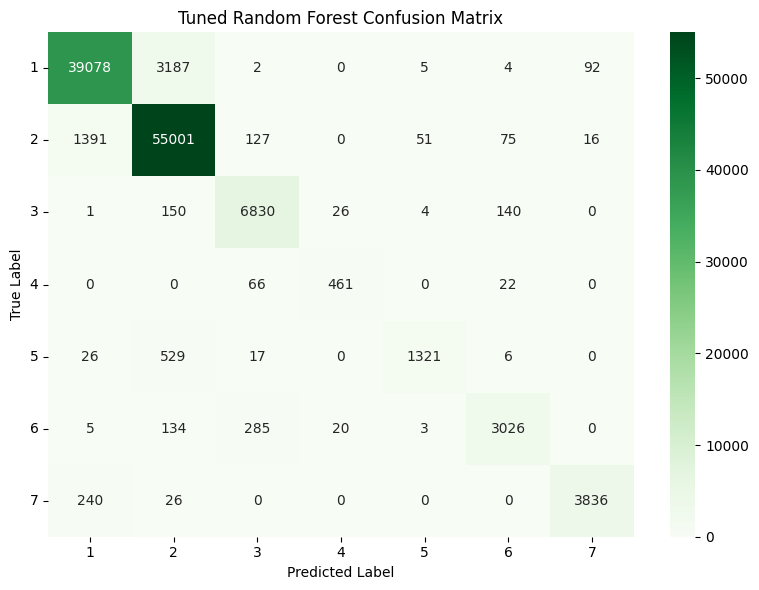

In [98]:
# Confusion Matrix
cm = confusion_matrix(

    y_test,

    rf_best_pred

)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens"

)

plt.title("Tuned Random Forest Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.xticks(

    np.arange(7)+0.5,

    labels=[1,2,3,4,5,6,7]

)

plt.yticks(

    np.arange(7)+0.5,

    labels=[1,2,3,4,5,6,7],

    rotation=0

)

plt.tight_layout()

plt.show()

In [99]:
# Performance Summary

rf_best_summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision (Macro)",

        "Precision (Weighted)",

        "Recall (Macro)",

        "Recall (Weighted)",

        "F1 Score (Macro)",

        "F1 Score (Weighted)"

    ],

    "Score":[

        rf_best_accuracy,

        rf_best_precision_macro,

        rf_best_precision_weighted,

        rf_best_recall_macro,

        rf_best_recall_weighted,

        rf_best_f1_macro,

        rf_best_f1_weighted

    ]

})

rf_best_summary["Score"] = rf_best_summary["Score"].round(4)

display(rf_best_summary)

,Metric,Score
0,Accuracy,0.9428
1,Precision (Macro),0.9406
2,Precision (Weighted),0.9433
3,Recall (Macro),0.8843
4,Recall (Weighted),0.9428
5,F1 Score (Macro),0.9090
6,F1 Score (Weighted),0.9423


In [100]:
# Baseline vs Tuned Random Forest
rf_comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision (Macro)",

        "Recall (Macro)",

        "F1 Score (Macro)",

        "Precision (Weighted)",

        "Recall (Weighted)",

        "F1 Score (Weighted)"

    ],

    "Baseline":[

        rf_accuracy,

        rf_precision_macro,

        rf_recall_macro,

        rf_f1_macro,

        rf_precision_weighted,

        rf_recall_weighted,

        rf_f1_weighted

    ],

    "Tuned":[

        rf_best_accuracy,

        rf_best_precision_macro,

        rf_best_recall_macro,

        rf_best_f1_macro,

        rf_best_precision_weighted,

        rf_best_recall_weighted,

        rf_best_f1_weighted

    ]

})

rf_comparison["Improvement"] = (

    rf_comparison["Tuned"] -

    rf_comparison["Baseline"]

).round(4)

display(rf_comparison.round(4))

,Metric,Baseline,Tuned,Improvement
0,Accuracy,0.9533,0.9428,-0.0106
1,Precision (Macro),0.9463,0.9406,-0.0057
2,Recall (Macro),0.9053,0.8843,-0.0210
3,F1 Score (Macro),0.9241,0.9090,-0.0150
4,Precision (Weighted),0.9535,0.9433,-0.0102
5,Recall (Weighted),0.9533,0.9428,-0.0106
6,F1 Score (Weighted),0.9531,0.9423,-0.0108


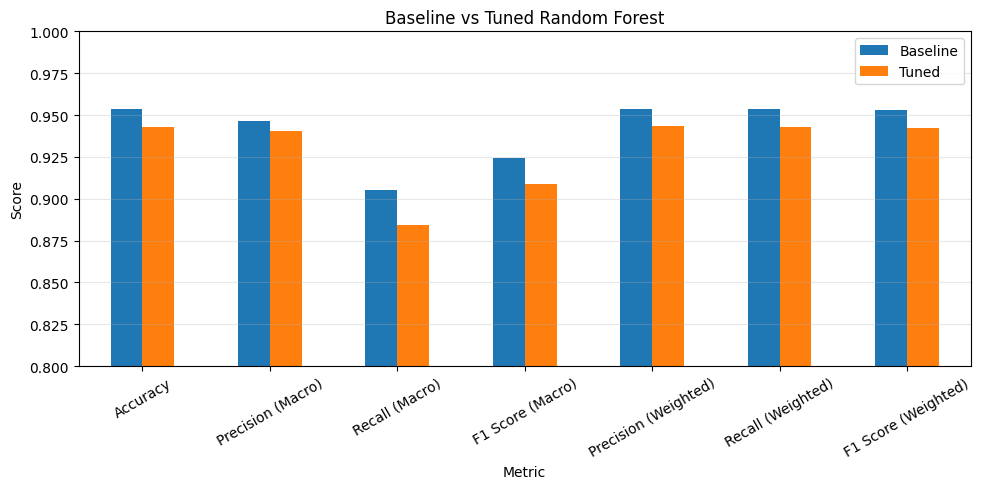

In [101]:
# Baseline vs Tuned Performance
plot_df = rf_comparison.set_index("Metric")[["Baseline","Tuned"]]

plot_df.plot(

    kind="bar",

    figsize=(10,5)

)

plt.title("Baseline vs Tuned Random Forest")

plt.ylabel("Score")

plt.ylim(0.80,1.00)

plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

Hypermeter Tuning -XGBoost Tuning

In [102]:
# Prepare Encoded Labels for Hyperparameter Tuning
y_tune_xgb = label_encoder.transform(y_tune)

print("="*50)
print("Encoded Tuning Labels Ready")
print("="*50)

print("Unique Classes :", np.unique(y_tune_xgb))

Encoded Tuning Labels Ready
Unique Classes : [0 1 2 3 4 5 6]


In [103]:
# XGBoost Hyperparameter Search Space
xgb_param_grid = {

    "n_estimators":[
        100,
        200,
        300
    ],

    "max_depth":[
        4,
        6,
        8,
        10
    ],

    "learning_rate":[
        0.01,
        0.05,
        0.1,
        0.2
    ],

    "subsample":[
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree":[
        0.7,
        0.8,
        1.0
    ],

    "min_child_weight":[
        1,
        3,
        5
    ]

}

print("Hyperparameter Search Space Ready")

Hyperparameter Search Space Ready


In [104]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

xgb_random = RandomizedSearchCV(

    estimator=XGBClassifier(

        objective="multi:softmax",

        num_class=7,

        eval_metric="mlogloss",

        random_state=RANDOM_STATE,

        n_jobs=-1

    ),

    param_distributions=xgb_param_grid,

    n_iter=10,

    scoring="f1_macro",

    cv=3,

    random_state=RANDOM_STATE,

    verbose=2,

    n_jobs=-1

)

In [105]:
# Hyperparameter Optimization
import time

start_time = time.time()

xgb_random.fit(

    X_tune,

    y_tune_xgb

)

end_time = time.time()

xgb_tuning_time = end_time - start_time

print("="*50)
print("Hyperparameter Search Completed")
print("="*50)

print(f"Tuning Time : {xgb_tuning_time:.2f} seconds")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Hyperparameter Search Completed
Tuning Time : 789.51 seconds


In [106]:
# Best Parameters
print("="*50)
print("Best XGBoost Parameters")
print("="*50)

print(xgb_random.best_params_)

Best XGBoost Parameters
{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


In [107]:
# Best Cross Validation Score
print("="*50)
print("Best Macro F1")
print("="*50)

print(f"{xgb_random.best_score_:.4f}")

Best Macro F1
0.8857


In [108]:
# Best Estimator
xgb_best = xgb_random.best_estimator_

print(xgb_best)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=7, ...)


In [109]:
# Retrain Best Model
start_train = time.time()

xgb_best.fit(

    X_train,

    y_train_xgb

)

end_train = time.time()

xgb_best_training_time = end_train - start_train

print("="*50)
print("Final Tuned XGBoost Trained")
print("="*50)

print(f"Training Time : {xgb_best_training_time:.2f} seconds")

Final Tuned XGBoost Trained
Training Time : 219.70 seconds


In [110]:
# Prediction
y_pred_best_encoded = xgb_best.predict(

    X_test

)

y_pred_best = label_encoder.inverse_transform(

    y_pred_best_encoded

)

print("Prediction Shape :", y_pred_best.shape)

Prediction Shape : (116203,)


Tuned XGBoost Evaluation

In [111]:
# Tuned XGBoost Accuracy
xgb_best_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print("="*50)
print("Tuned XGBoost Accuracy")
print("="*50)

print(f"Accuracy : {xgb_best_accuracy:.4f}")

Tuned XGBoost Accuracy
Accuracy : 0.9648


In [112]:
# Precision
xgb_best_precision_macro = precision_score(
    y_test,
    y_pred_best,
    average="macro"
)

xgb_best_precision_weighted = precision_score(
    y_test,
    y_pred_best,
    average="weighted"
)

print(f"Macro Precision    : {xgb_best_precision_macro:.4f}")
print(f"Weighted Precision : {xgb_best_precision_weighted:.4f}")

Macro Precision    : 0.9491
Weighted Precision : 0.9648


In [113]:
# Recall
xgb_best_recall_macro = recall_score(
    y_test,
    y_pred_best,
    average="macro"
)

xgb_best_recall_weighted = recall_score(
    y_test,
    y_pred_best,
    average="weighted"
)

print(f"Macro Recall    : {xgb_best_recall_macro:.4f}")
print(f"Weighted Recall : {xgb_best_recall_weighted:.4f}")

Macro Recall    : 0.9351
Weighted Recall : 0.9648


In [114]:
# F1 Score
xgb_best_f1_macro = f1_score(
    y_test,
    y_pred_best,
    average="macro"
)

xgb_best_f1_weighted = f1_score(
    y_test,
    y_pred_best,
    average="weighted"
)

print(f"Macro F1 Score    : {xgb_best_f1_macro:.4f}")
print(f"Weighted F1 Score : {xgb_best_f1_weighted:.4f}")

Macro F1 Score    : 0.9420
Weighted F1 Score : 0.9647


In [115]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           1       0.97      0.96      0.96     42368
           2       0.97      0.98      0.97     56661
           3       0.96      0.97      0.96      7151
           4       0.91      0.87      0.89       549
           5       0.93      0.88      0.91      1899
           6       0.94      0.93      0.93      3473
           7       0.97      0.96      0.97      4102

    accuracy                           0.96    116203
   macro avg       0.95      0.94      0.94    116203
weighted avg       0.96      0.96      0.96    116203



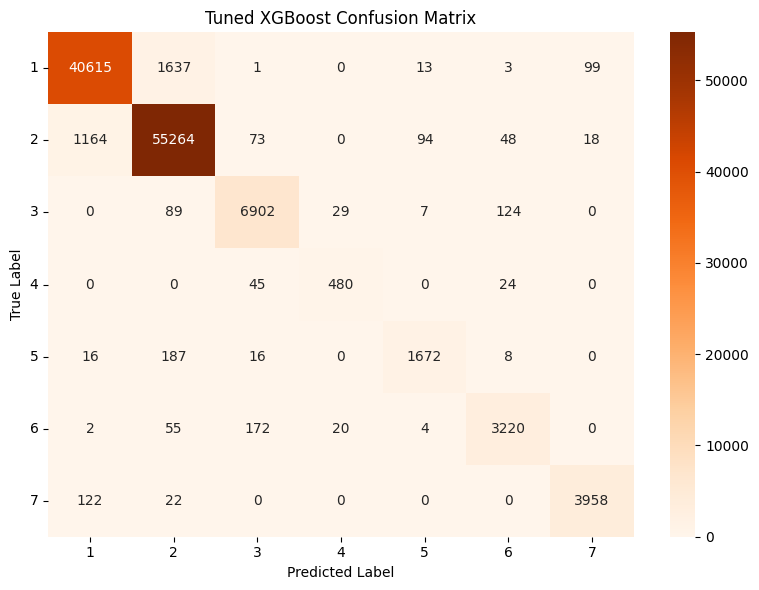

In [116]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Tuned XGBoost Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    np.arange(7)+0.5,
    labels=[1,2,3,4,5,6,7]
)

plt.yticks(
    np.arange(7)+0.5,
    labels=[1,2,3,4,5,6,7],
    rotation=0
)

plt.tight_layout()

plt.show()

In [117]:
# Tuned XGBoost Performance Summary
xgb_best_summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision (Macro)",

        "Precision (Weighted)",

        "Recall (Macro)",

        "Recall (Weighted)",

        "F1 Score (Macro)",

        "F1 Score (Weighted)"

    ],

    "Score":[

        xgb_best_accuracy,

        xgb_best_precision_macro,

        xgb_best_precision_weighted,

        xgb_best_recall_macro,

        xgb_best_recall_weighted,

        xgb_best_f1_macro,

        xgb_best_f1_weighted

    ]

})

xgb_best_summary["Score"] = xgb_best_summary["Score"].round(4)

display(xgb_best_summary)

,Metric,Score
0,Accuracy,0.9648
1,Precision (Macro),0.9491
2,Precision (Weighted),0.9648
3,Recall (Macro),0.9351
4,Recall (Weighted),0.9648
5,F1 Score (Macro),0.9420
6,F1 Score (Weighted),0.9647


In [118]:
# Baseline vs Tuned XGBoost Comparison
xgb_comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision (Macro)",

        "Recall (Macro)",

        "F1 Score (Macro)",

        "Precision (Weighted)",

        "Recall (Weighted)",

        "F1 Score (Weighted)"

    ],

    "Baseline":[

        xgb_accuracy,

        xgb_precision_macro,

        xgb_recall_macro,

        xgb_f1_macro,

        xgb_precision_weighted,

        xgb_recall_weighted,

        xgb_f1_weighted

    ],

    "Tuned":[

        xgb_best_accuracy,

        xgb_best_precision_macro,

        xgb_best_recall_macro,

        xgb_best_f1_macro,

        xgb_best_precision_weighted,

        xgb_best_recall_weighted,

        xgb_best_f1_weighted

    ]

})

xgb_comparison["Improvement"] = (

    xgb_comparison["Tuned"] -

    xgb_comparison["Baseline"]

).round(4)

display(xgb_comparison.round(4))

,Metric,Baseline,Tuned,Improvement
0,Accuracy,0.8682,0.9648,0.0966
1,Precision (Macro),0.8764,0.9491,0.0727
2,Recall (Macro),0.8305,0.9351,0.1046
3,F1 Score (Macro),0.8508,0.9420,0.0912
4,Precision (Weighted),0.8681,0.9648,0.0967
5,Recall (Weighted),0.8682,0.9648,0.0966
6,F1 Score (Weighted),0.8677,0.9647,0.0971


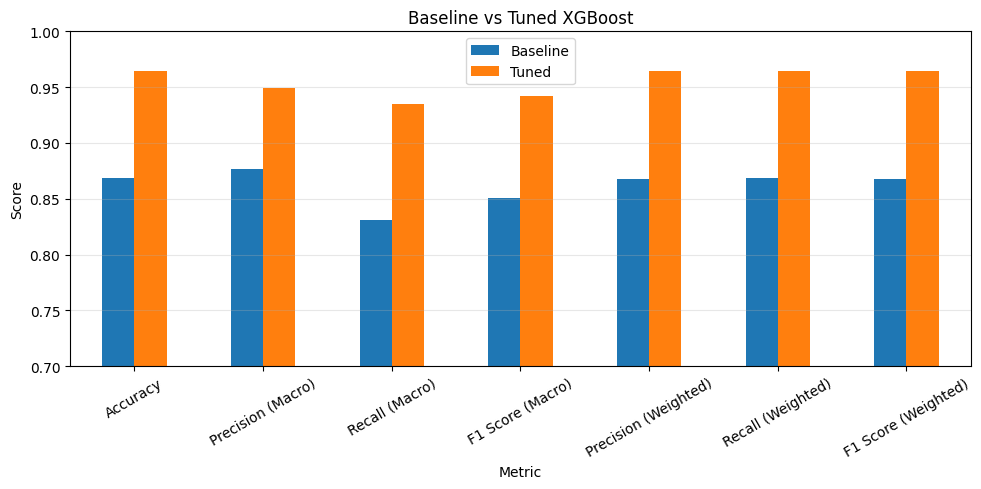

In [119]:
# Baseline vs Tuned XGBoost
plot_df = xgb_comparison.set_index("Metric")[["Baseline","Tuned"]]

plot_df.plot(

    kind="bar",

    figsize=(10,5)

)

plt.title("Baseline vs Tuned XGBoost")

plt.ylabel("Score")

plt.ylim(0.70,1.00)

plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

Final Model Comparison

In [121]:
# Final Model Performance Comparison
comparison_df = pd.DataFrame({

    "Model":[

        "Random Forest (Baseline)",

        "Random Forest (Tuned)",

        "XGBoost (Baseline)",

        "XGBoost (Tuned)"

    ],

    "Accuracy":[

        rf_accuracy,

        rf_best_accuracy,

        xgb_accuracy,

        xgb_best_accuracy

    ],

    "Macro Precision":[

        rf_precision_macro,

        rf_best_precision_macro,

        xgb_precision_macro,

        xgb_best_precision_macro

    ],

    "Macro Recall":[

        rf_recall_macro,

        rf_best_recall_macro,

        xgb_recall_macro,

        xgb_best_recall_macro

    ],

    "Macro F1":[

        rf_f1_macro,

        rf_best_f1_macro,

        xgb_f1_macro,

        xgb_best_f1_macro

    ],

    "Weighted F1":[

        rf_f1_weighted,

        rf_best_f1_weighted,

        xgb_f1_weighted,

        xgb_best_f1_weighted

    ]

})

comparison_df = comparison_df.round(4)

display(comparison_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Random Forest (Baseline),0.9533,0.9463,0.9053,0.9241,0.9531
1,Random Forest (Tuned),0.9428,0.9406,0.8843,0.9090,0.9423
2,XGBoost (Baseline),0.8682,0.8764,0.8305,0.8508,0.8677
3,XGBoost (Tuned),0.9648,0.9491,0.9351,0.9420,0.9647


In [122]:
# Model Ranking
ranking = comparison_df.sort_values(

    by=["Macro F1","Accuracy"],

    ascending=False

).reset_index(drop=True)

ranking.index = ranking.index + 1

display(ranking)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,XGBoost (Tuned),0.9648,0.9491,0.9351,0.9420,0.9647
2,Random Forest (Baseline),0.9533,0.9463,0.9053,0.9241,0.9531
3,Random Forest (Tuned),0.9428,0.9406,0.8843,0.9090,0.9423
4,XGBoost (Baseline),0.8682,0.8764,0.8305,0.8508,0.8677


In [123]:
# Best Performing Model
best_model = ranking.iloc[0]

print("="*60)

print("🏆 BEST MODEL")

print("="*60)

print(f"Model      : {best_model['Model']}")

print(f"Accuracy   : {best_model['Accuracy']:.4f}")

print(f"Macro F1   : {best_model['Macro F1']:.4f}")

🏆 BEST MODEL
Model      : XGBoost (Tuned)
Accuracy   : 0.9648
Macro F1   : 0.9420


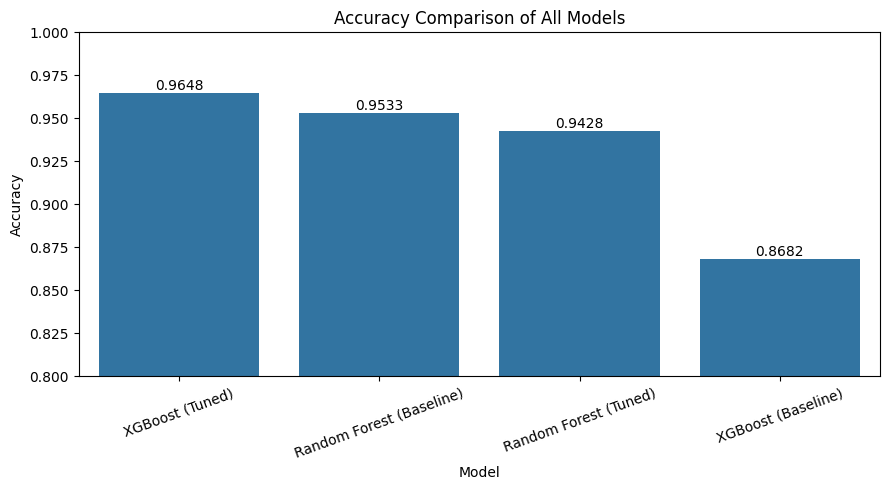

In [142]:
# Accuracy Comparison
plt.figure(figsize=(9,5))

ax = sns.barplot(

    data=comparison_df,

    x="Model",

    y="Accuracy"

)

plt.title("Accuracy Comparison of All Models")

plt.xticks(rotation=20)

plt.ylim(0.80,1.00)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.tight_layout()
plt.savefig(
    "images/09_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

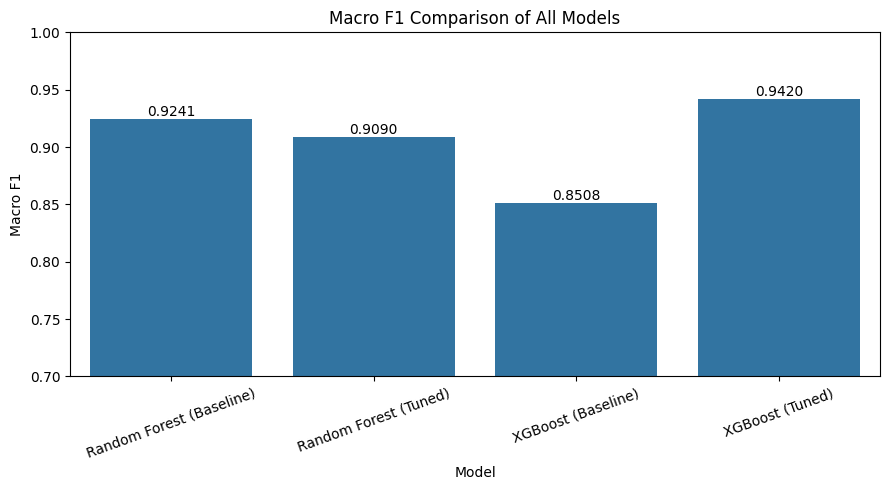

In [125]:
# Macro F1 Comparison
plt.figure(figsize=(9,5))

ax = sns.barplot(

    data=comparison_df,

    x="Model",

    y="Macro F1"

)

plt.title("Macro F1 Comparison of All Models")

plt.xticks(rotation=20)

plt.ylim(0.70,1.00)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.tight_layout()

plt.show()

In [145]:
# Category Winners
winner_table = pd.DataFrame({

    "Category":[

        "Highest Accuracy",

        "Highest Macro Precision",

        "Highest Macro Recall",

        "Highest Macro F1",

        "Highest Weighted F1"

    ],

    "Winner":[

        comparison_df.loc[
            comparison_df["Accuracy"].idxmax(),
            "Model"
        ],

        comparison_df.loc[
            comparison_df["Macro Precision"].idxmax(),
            "Model"
        ],

        comparison_df.loc[
            comparison_df["Macro Recall"].idxmax(),
            "Model"
        ],

        comparison_df.loc[
            comparison_df["Macro F1"].idxmax(),
            "Model"
        ],

        comparison_df.loc[
            comparison_df["Weighted F1"].idxmax(),
            "Model"
        ]

    ]

})

display(winner_table)
plt.tight_layout()

plt.savefig(
    "images/10_winner_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Category,Winner
0,Highest Accuracy,XGBoost (Tuned)
1,Highest Macro Precision,XGBoost (Tuned)
2,Highest Macro Recall,XGBoost (Tuned)
3,Highest Macro F1,XGBoost (Tuned)
4,Highest Weighted F1,XGBoost (Tuned)


<Figure size 640x480 with 0 Axes>